In [1]:
# Week 9 — Linear Regression from Scratch
# Prajwal Kondala | IIT KGP → AI/ML Engineer
# Date: April 21, 2026
# Goal: Implement Linear Regression using ONLY NumPy
# No sklearn yet! Pure understanding!

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Loading California Housing Dataset
from sklearn.datasets import fetch_california_housing

# Load data
housing = fetch_california_housing()

print("Feature names:", housing.feature_names)
print("Dataset shape:", housing.data.shape)
print("Target shape:", housing.target.shape)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset shape: (20640, 8)
Target shape: (20640,)


In [4]:
# Convert to numpy arrays
X = housing.data
y = housing.target

# Look at first 5 houses
print("First 5 houses (features):")
print(X[:5])
print("\nFirst 5 house prices:")
print(y[:5])

First 5 houses (features):
[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]

First 5 house prices:
[4.526 3.585 3.521 3.413 3.422]


In [5]:
# Data exploration
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nPrice Statistics:")
print("Min price:", y.min())
print("Max price:", y.max())
print("Mean price:", y.mean().round(2))
print("\nFeature Statistics:")
print("Mean of each feature:", X.mean(axis=0).round(2))

X shape: (20640, 8)
y shape: (20640,)

Price Statistics:
Min price: 0.14999
Max price: 5.00001
Mean price: 2.07

Feature Statistics:
Mean of each feature: [ 3.87000e+00  2.86400e+01  5.43000e+00  1.10000e+00  1.42548e+03
  3.07000e+00  3.56300e+01 -1.19570e+02]


In [6]:
# Feature Scaling — Standardization
# Mean = 0, Standard Deviation = 1

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

print("Before scaling - MedInc mean:", X[:,0].mean().round(2))
print("After scaling  - MedInc mean:", X_scaled[:,0].mean().round(2))
print("\nBefore scaling - Population mean:", X[:,4].mean().round(2))
print("After scaling  - Population mean:", X_scaled[:,4].mean().round(2))

Before scaling - MedInc mean: 3.87
After scaling  - MedInc mean: 0.0

Before scaling - Population mean: 1425.48
After scaling  - Population mean: -0.0


In [7]:
# Train Test Split — 80% train, 20% test
# Manually — no sklearn yet!

split = int(0.8 * len(X_scaled))

X_train = X_scaled[:split]
X_test  = X_scaled[split:]
y_train = y[:split]
y_test  = y[split:]

print("Total houses    :", len(X_scaled))
print("Training houses :", len(X_train))
print("Testing houses  :", len(X_test))

Total houses    : 20640
Training houses : 16512
Testing houses  : 4128


In [8]:
# Add bias column (column of 1s) to X
# This represents θ₀ in our equation!

X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_b  = np.c_[np.ones((len(X_test), 1)), X_test]

print("X_train shape before bias:", X_train.shape)
print("X_train shape after bias :", X_train_b.shape)

X_train shape before bias: (16512, 8)
X_train shape after bias : (16512, 9)


In [9]:
# Initialize theta (weights) — all zeros!
# 9 values — one for each feature + bias!

theta = np.zeros(X_train_b.shape[1])

print("Initial theta shape:", theta.shape)
print("Initial theta values:", theta)
print("All zeros — model knows nothing yet!")

Initial theta shape: (9,)
Initial theta values: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
All zeros — model knows nothing yet!


In [10]:
# Predict function — the heart of our model!
# ŷ = X @ θ — matrix multiplication!

def predict(X, theta):
    return X @ theta

# Test prediction with initial theta (all zeros)
y_pred_initial = predict(X_train_b, theta)

print("Prediction shape:", y_pred_initial.shape)
print("First 5 predictions:", y_pred_initial[:5])
print("First 5 actual prices:", y_train[:5])

Prediction shape: (16512,)
First 5 predictions: [0. 0. 0. 0. 0.]
First 5 actual prices: [4.526 3.585 3.521 3.413 3.422]


In [11]:
# Cost Function — MSE
# Measures how wrong our model currently is!

def compute_cost(X, y, theta):
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

# Calculate initial cost
initial_cost = compute_cost(X_train_b, y_train, theta)
print("Initial cost (all zeros theta):", initial_cost.round(4))
print("This is how WRONG our model is right now!")

Initial cost (all zeros theta): 2.6859
This is how WRONG our model is right now!


In [12]:
# Gradient Descent — where learning happens!

def gradient_descent(X, y, theta, learning_rate, epochs):
    m = len(y)
    cost_history = []

    for epoch in range(epochs):
        # Step 1: Predict
        predictions = predict(X, theta)

        # Step 2: Calculate error
        errors = predictions - y

        # Step 3: Calculate gradient
        gradient = (1/m) * X.T @ errors

        # Step 4: Update theta
        theta = theta - learning_rate * gradient

        # Step 5: Record cost
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

        # Print every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Cost = {cost:.4f}")

    return theta, cost_history

# Run gradient descent!
learning_rate = 0.01
epochs = 1000

theta_trained, cost_history = gradient_descent(
    X_train_b, y_train, theta, learning_rate, epochs
)

print("\nFinal theta values:", theta_trained.round(4))

Epoch 0: Cost = 2.6349
Epoch 100: Cost = 0.6439
Epoch 200: Cost = 0.3703
Epoch 300: Cost = 0.3208
Epoch 400: Cost = 0.3079
Epoch 500: Cost = 0.3017
Epoch 600: Cost = 0.2972
Epoch 700: Cost = 0.2935
Epoch 800: Cost = 0.2903
Epoch 900: Cost = 0.2875

Final theta values: [ 2.0376  0.8225  0.1981 -0.1431  0.1533  0.0229 -0.1084 -0.3994 -0.3359]


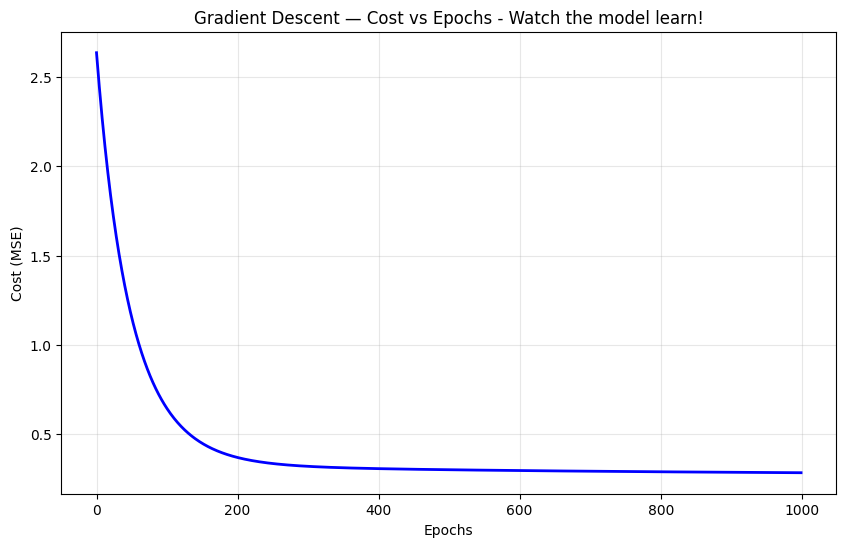

Chart saved!


In [13]:
# Visualize cost decreasing over epochs!

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), cost_history,
         color='blue', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent — Cost vs Epochs - Watch the model learn!')
plt.grid(True, alpha=0.3)
plt.savefig('cost_convergence.png',
             bbox_inches='tight')
plt.show()

print("Chart saved!")

In [14]:
# Evaluate on Test Set!

y_pred_test = predict(X_test_b, theta_trained)

# Calculate metrics
mse = np.mean((y_pred_test - y_test) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("=" * 40)
print("MODEL EVALUATION — TEST SET")
print("=" * 40)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print("=" * 40)
print(f"\nFirst 5 predictions vs actual:")
for i in range(5):
    print(f"Predicted: {y_pred_test[i]:.2f} | Actual: {y_test[i]:.2f}")

MODEL EVALUATION — TEST SET
MSE  : 0.5715
RMSE : 0.7560
R²   : 0.6078

First 5 predictions vs actual:
Predicted: 1.43 | Actual: 1.66
Predicted: 1.60 | Actual: 1.26
Predicted: 1.17 | Actual: 0.94
Predicted: 1.29 | Actual: 0.92
Predicted: 1.36 | Actual: 1.24


In [15]:
# =============================================
# PART 2 — sklearn Implementation
# Same problem — One line training!
# Goal: Compare with our NumPy scratch results!
# =============================================

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("sklearn imported successfully!")

sklearn imported successfully!


In [17]:
# Fresh data reload
# sklearn train_test_split — proper way!

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target

# random_state=42 → same split every run!
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train_sk.shape)
print("Testing set :", X_test_sk.shape)

Training set: (16512, 8)
Testing set : (4128, 8)


In [18]:
# StandardScaler — same as our Z-score

scaler = StandardScaler()

# fit_transform on TRAINING data ONLY!
X_train_scaled = scaler.fit_transform(X_train_sk)

# Only TRANSFORM on test — never fit!
X_test_scaled = scaler.transform(X_test_sk)

print("Train mean (should be ~0):",
      X_train_scaled.mean(axis=0).round(2))
print("Train std (should be ~1):",
      X_train_scaled.std(axis=0).round(2))

Train mean (should be ~0): [-0. -0.  0. -0. -0. -0.  0. -0.]
Train std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [19]:
# Create and train Linear Regression!
# This ONE line = our entire gradient_descent() function!

model_sk = LinearRegression()
model_sk.fit(X_train_scaled, y_train_sk)

print("Model trained!")
print("\nLearned coefficients (our theta values!):")
print(model_sk.coef_.round(4))
print("\nBias term (our theta_0!):")
print(model_sk.intercept_.round(4))

Model trained!

Learned coefficients (our theta values!):
[ 0.8544  0.1225 -0.2944  0.3393 -0.0023 -0.0408 -0.8969 -0.8698]

Bias term (our theta_0!):
2.0719


In [20]:
# Predict on test set
y_pred_sk = model_sk.predict(X_test_scaled)

# Calculating metrics
mse_sk  = mean_squared_error(y_test_sk, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
r2_sk   = r2_score(y_test_sk, y_pred_sk)

print("=" * 45)
print("sklearn MODEL EVALUATION")
print("=" * 45)
print(f"MSE  : {mse_sk:.4f}")
print(f"RMSE : {rmse_sk:.4f}")
print(f"R²   : {r2_sk:.4f}")
print("=" * 45)

sklearn MODEL EVALUATION
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


In [21]:
print("=" * 50)
print("COMPARISON: NumPy Scratch vs sklearn")
print("=" * 50)
print(f"{'Metric':<10} {'Scratch':>12} {'sklearn':>12}")
print("-" * 50)
print(f"{'MSE':<10} {0.5715:>12.4f} {mse_sk:>12.4f}")
print(f"{'RMSE':<10} {0.7560:>12.4f} {rmse_sk:>12.4f}")
print(f"{'R²':<10} {0.6078:>12.4f} {r2_sk:>12.4f}")
print("=" * 50)
print("\nNote: Different splits explain the difference!")
print("Same data — different test sets after shuffling!")

COMPARISON: NumPy Scratch vs sklearn
Metric          Scratch      sklearn
--------------------------------------------------
MSE              0.5715       0.5559
RMSE             0.7560       0.7456
R²               0.6078       0.5758

Note: Different splits explain the difference!
Same data — different test sets after shuffling!


In [22]:
# Redo scratch with same random_state split!
X_train_fix, X_test_fix, y_train_fix, y_test_fix = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scaling properly
scaler_fix = StandardScaler()
X_train_fix_scaled = scaler_fix.fit_transform(X_train_fix)
X_test_fix_scaled  = scaler_fix.transform(X_test_fix)

# Add bias column
X_train_fix_b = np.c_[np.ones((len(X_train_fix_scaled), 1)),
                        X_train_fix_scaled]
X_test_fix_b  = np.c_[np.ones((len(X_test_fix_scaled), 1)),
                        X_test_fix_scaled]

# Initialize and train
theta_fix = np.zeros(X_train_fix_b.shape[1])
theta_fix, cost_fix = gradient_descent(
    X_train_fix_b, y_train_fix,
    theta_fix, 0.01, 1000
)

# Evaluate
y_pred_fix = predict(X_test_fix_b, theta_fix)
mse_fix = np.mean((y_pred_fix - y_test_fix)**2)
r2_fix  = 1 - (np.sum((y_test_fix - y_pred_fix)**2) /
               np.sum((y_test_fix - y_test_fix.mean())**2))

print("=" * 50)
print("FAIR COMPARISON — Same Split!")
print("=" * 50)
print(f"{'Metric':<10} {'Scratch':>12} {'sklearn':>12}")
print("-" * 50)
print(f"{'R²':<10} {r2_fix:>12.4f} {r2_sk:>12.4f}")
print(f"{'RMSE':<10} {np.sqrt(mse_fix):>12.4f} {np.sqrt(mse_sk):>12.4f}")
print("=" * 50)
print("\nNow SAME test set — fair comparison!")
print("sklearn should be >= scratch (Normal Equation!)")

Epoch 0: Cost = 2.7650
Epoch 100: Cost = 0.6453
Epoch 200: Cost = 0.3551
Epoch 300: Cost = 0.3094
Epoch 400: Cost = 0.2976
Epoch 500: Cost = 0.2914
Epoch 600: Cost = 0.2866
Epoch 700: Cost = 0.2826
Epoch 800: Cost = 0.2792
Epoch 900: Cost = 0.2763
FAIR COMPARISON — Same Split!
Metric          Scratch      sklearn
--------------------------------------------------
R²               0.5672       0.5758
RMSE             0.7531       0.7456

Now SAME test set — fair comparison!
sklearn should be >= scratch (Normal Equation!)


In [23]:
# Normal Equation — exact solution in ONE line!
# θ = (XᵀX)⁻¹ Xᵀy

X_train_fix_b_ne = np.c_[np.ones((len(X_train_fix_scaled), 1)),
                           X_train_fix_scaled]
X_test_fix_b_ne  = np.c_[np.ones((len(X_test_fix_scaled), 1)),
                           X_test_fix_scaled]

# The Normal Equation!
theta_ne = np.linalg.inv(X_train_fix_b_ne.T @ X_train_fix_b_ne) \
           @ X_train_fix_b_ne.T @ y_train_fix

# Predicting and evaluating
y_pred_ne = X_test_fix_b_ne @ theta_ne
r2_ne = 1 - (np.sum((y_test_fix - y_pred_ne)**2) /
             np.sum((y_test_fix - y_test_fix.mean())**2))

print("Normal Equation theta values:")
print(theta_ne.round(4))
print(f"\nNormal Equation R²: {r2_ne:.4f}")
print(f"sklearn R²        : {r2_sk:.4f}")
print(f"Scratch R²        : {r2_fix:.4f}")
print("\nNormal Equation ≈ sklearn — both exact! 🎯")

Normal Equation theta values:
[ 2.0719  0.8544  0.1225 -0.2944  0.3393 -0.0023 -0.0408 -0.8969 -0.8698]

Normal Equation R²: 0.5758
sklearn R²        : 0.5758
Scratch R²        : 0.5672

Normal Equation ≈ sklearn — both exact! 🎯


In [24]:
# Feature Importance Analysis!
# Larger |coefficient| = more impact on price!

feature_names = housing.feature_names
coefficients  = model_sk.coef_

print("Feature Importance (sorted by impact):")
print("=" * 45)

# Sort by absolute value
importance = list(zip(feature_names, coefficients))
importance.sort(key=lambda x: abs(x[1]), reverse=True)

for feat, coef in importance:
    direction = "↑ price" if coef > 0 else "↓ price"
    print(f"{feat:<12} {coef:>8.4f}  {direction}")

print("=" * 45)
print("\nPositive → increases price")
print("Negative → decreases price")

Feature Importance (sorted by impact):
Latitude      -0.8969  ↓ price
Longitude     -0.8698  ↓ price
MedInc         0.8544  ↑ price
AveBedrms      0.3393  ↑ price
AveRooms      -0.2944  ↓ price
HouseAge       0.1225  ↑ price
AveOccup      -0.0408  ↓ price
Population    -0.0023  ↓ price

Positive → increases price
Negative → decreases price


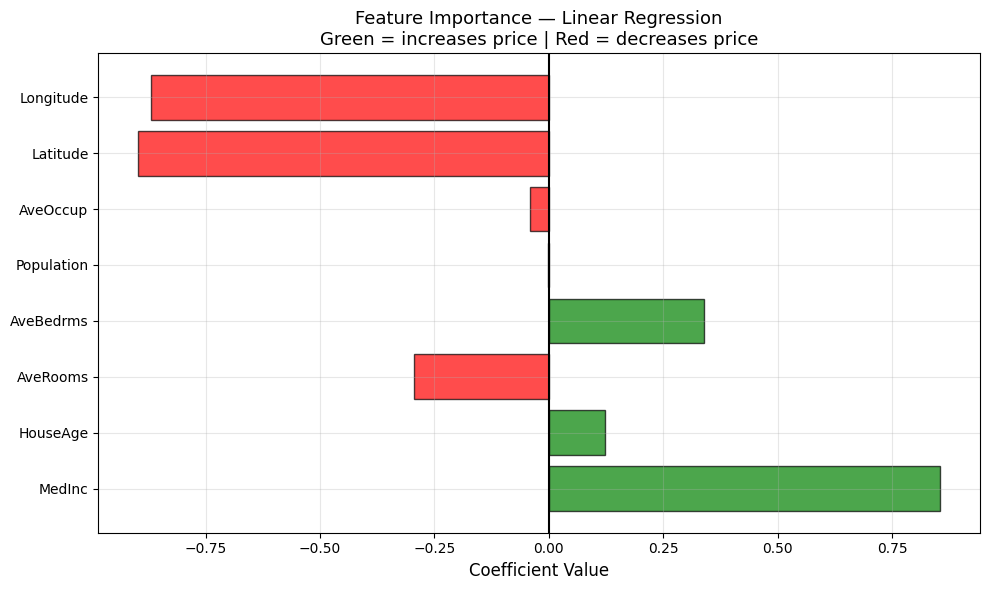

Chart saved!


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if c > 0 else 'red'
          for c in coefficients]

ax.barh(feature_names, coefficients,
        color=colors, alpha=0.7,
        edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Feature Importance — Linear Regression\n'
             'Green = increases price | Red = decreases price',
             fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

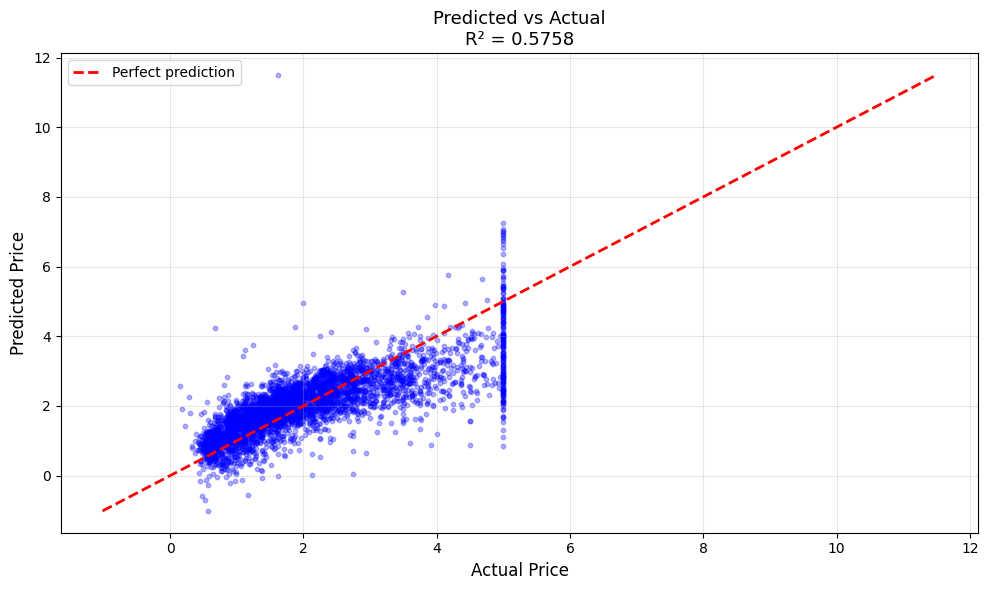

Chart saved!


In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(y_test_fix, y_pred_sk,
           alpha=0.3, color='blue', s=10)

min_val = min(y_test_fix.min(), y_pred_sk.min())
max_val = max(y_test_fix.max(), y_pred_sk.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual Price', fontsize=12)
ax.set_ylabel('Predicted Price', fontsize=12)
ax.set_title(f'Predicted vs Actual\nR² = {r2_sk:.4f}',
             fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

In [28]:
print("=" * 55)
print("COMPLETE WEEK 9 SUMMARY")
print("=" * 55)
print(f"\n{'Method':<20} {'R²':>8} {'RMSE':>10}")
print("-" * 55)
print(f"{'NumPy Scratch':<20} {r2_fix:>8.4f} "
      f"{np.sqrt(mse_fix):>10.4f}")
print(f"{'Normal Equation':<20} {r2_ne:>8.4f} "
      f"{np.sqrt(np.mean((y_pred_ne - y_test_fix)**2)):>10.4f}")
print(f"{'sklearn':<20} {r2_sk:>8.4f} "
      f"{np.sqrt(mse_sk):>10.4f}")
print("=" * 55)
print(f"\nTop predictor: MedInc (coef = 0.8544)")
print(f"Location impact: Latitude + Longitude combined!")
print(f"Dataset limitation: prices capped at $500,001!")

COMPLETE WEEK 9 SUMMARY

Method                     R²       RMSE
-------------------------------------------------------
NumPy Scratch          0.5672     0.7531
Normal Equation        0.5758     0.7456
sklearn                0.5758     0.7456

Top predictor: MedInc (coef = 0.8544)
Location impact: Latitude + Longitude combined!
Dataset limitation: prices capped at $500,001!


In [29]:
# trained model and scaler!
import pickle

# sklearn model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model_sk, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ house_price_model.pkl saved!")
print("✅ scaler.pkl saved!")
print("\nNow download both from Colab Files panel!")

✅ house_price_model.pkl saved!
✅ scaler.pkl saved!

Now download both from Colab Files panel!
